# 07 · Figuras 8 a 13 para el documento

Proyecto de titulación · **Maestría en Inteligencia Artificial Aplicada (UDLA)**

Genera como **imagen PNG** las seis figuras que pide el documento. No son capturas de pantalla de
celdas: son figuras compuestas, con la misma paleta que el resto del trabajo, legibles al insertarse
en Word y sin bordes de navegador ni barras de desplazamiento.

| Figura | Contenido | Archivo |
|---|---|---|
| 8 | Primeras filas del dataset final | `fig08_primeras_filas_dataset.png` |
| 9 | Diccionario de datos | `fig09_diccionario_datos.png` |
| 10 | Distribución del target | `fig10_distribucion_target.png` |
| 11 | Normalización de cédula | `fig11_normalizacion_cedula.png` |
| 12 | Auditoría PII | `fig12_auditoria_pii.png` |
| 13 | JSON del prototipo, tres casos | `fig13_json_prototipo.png` |

Todas se guardan en `outputs/figuras_documento/`, separadas de `outputs/figuras/` para que no se
mezclen con las figuras analíticas de los notebooks 02 a 05.

## 0 · Configuración y utilidades de render

In [1]:
import hashlib
import json
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_OUTPUTS = RAIZ / "outputs"
DIR_FIGS = DIR_OUTPUTS / "figuras_documento"
DIR_FIGS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(RAIZ / "prototipo"))

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
ROJO, AMARILLO, VERDE = "#d03b3b", "#fab219", "#0ca30c"
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, REJILLA, EJE = "#898781", "#e1e0d9", "#c3c2b7"
FILA_ALT = "#f4f3ef"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "savefig.dpi": 220, "savefig.bbox": "tight", "figure.dpi": 110,
})

def guardar(fig, nombre):
    ruta = DIR_FIGS / f"{nombre}.png"
    fig.savefig(ruta)
    print(f"-> {ruta.relative_to(RAIZ)}")

In [2]:
def tabla_figura(datos, titulo, subtitulo=None, nombre=None, fontsize=7.5,
                 anchos=None, alto_fila=0.30, mono=None, ax=None):
    """Dibuja un DataFrame como tabla limpia. `mono`: columnas en monoespaciada."""
    mono = mono or []
    n_fil, n_col = datos.shape
    propio = ax is None
    if propio:
        ancho = min(17, max(7, 0.95 * n_col + 1.5))
        alto = alto_fila * (n_fil + 1) + (1.35 if titulo else 0.4)
        fig, ax = plt.subplots(figsize=(ancho, alto))
    else:
        fig = ax.figure
    ax.axis("off")

    tabla = ax.table(cellText=datos.astype(str).values,
                     colLabels=list(datos.columns),
                     cellLoc="left", loc="upper center",
                     colWidths=anchos)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(fontsize)
    tabla.scale(1, 1.45)

    columnas = list(datos.columns)
    for (fila, col), celda in tabla.get_celld().items():
        celda.set_edgecolor(REJILLA)
        celda.set_linewidth(0.6)
        celda.PAD = 0.035
        if fila == 0:
            celda.set_facecolor(AZUL)
            celda.set_text_props(color="white", fontweight="600")
            celda.set_height(celda.get_height() * 1.12)
        else:
            celda.set_facecolor(SUPERFICIE if fila % 2 else FILA_ALT)
            celda.set_text_props(color=TINTA_2)
            if columnas[col] in mono:
                celda.set_text_props(family="DejaVu Sans Mono", size=fontsize - 0.8)

    if titulo:
        ax.set_title("")
        y = 1.0 if not propio else 1.02
        ax.text(0, y + (0.06 if subtitulo else 0.0), titulo, transform=ax.transAxes,
                fontsize=12, fontweight="600", color=TINTA, va="bottom")
        if subtitulo:
            ax.text(0, y, subtitulo, transform=ax.transAxes, fontsize=8.5,
                    color=MUTED, va="bottom")
    if propio and nombre:
        guardar(fig, nombre)
    return fig, ax


def panel_texto(lineas, titulo, subtitulo, nombre, ancho=13, fontsize=9,
                color_barra=AZUL):
    """Panel de texto monoespaciado con una barra de color a la izquierda."""
    alto = 0.235 * len(lineas) + 1.5
    fig, ax = plt.subplots(figsize=(ancho, alto))
    ax.axis("off")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.add_patch(mpl.patches.Rectangle((0, 0), 0.006, 1, transform=ax.transAxes,
                                       color=color_barra, clip_on=False))
    ax.text(0, 1.10, titulo, transform=ax.transAxes, fontsize=12,
            fontweight="600", color=TINTA, va="bottom")
    ax.text(0, 1.02, subtitulo, transform=ax.transAxes, fontsize=8.5,
            color=MUTED, va="bottom")
    ax.text(0.018, 0.97, "\n".join(lineas), transform=ax.transAxes,
            fontsize=fontsize, family="DejaVu Sans Mono", color=TINTA_2,
            va="top", linespacing=1.5)
    guardar(fig, nombre)
    return fig

---
## Figura 8 · Primeras filas del dataset final

dataset_clientemes_v1.csv: 21,642 filas x 19 columnas


-> outputs\figuras_documento\fig08_primeras_filas_dataset.png


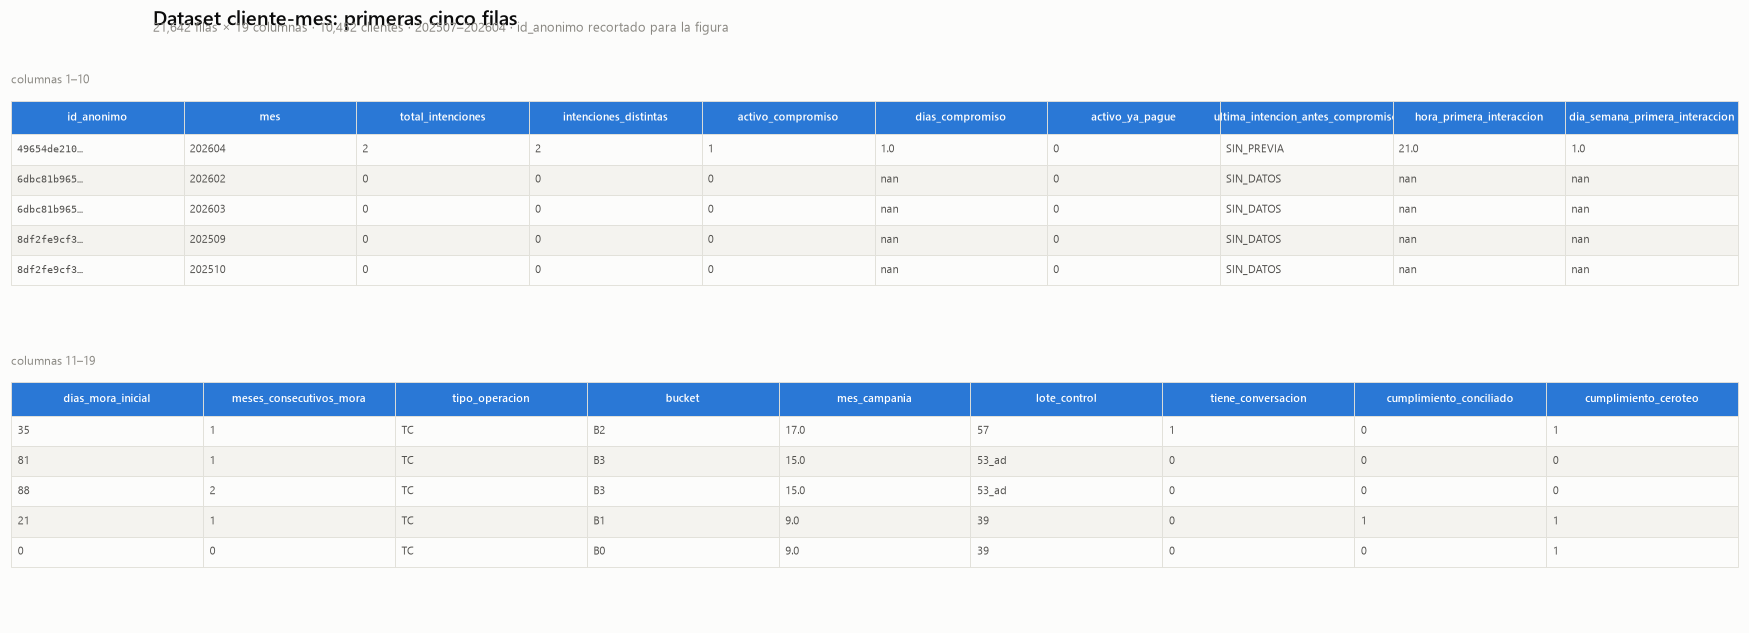

In [3]:
dataset = pd.read_csv(DIR_OUTPUTS / "dataset_clientemes_v1.csv",
                      dtype={"mes": str, "id_anonimo": str})
print(f"dataset_clientemes_v1.csv: {dataset.shape[0]:,} filas x {dataset.shape[1]} columnas")

muestra = dataset.head(5).copy()
# El hash ocupa 64 caracteres: se recorta solo para que la figura sea legible
muestra["id_anonimo"] = muestra["id_anonimo"].str[:10] + "…"
for c in muestra.columns:
    muestra[c] = muestra[c].astype(str).replace({"<NA>": "—", "nan": "—", "None": "—"})

cols = list(muestra.columns)
mitad = 10
grupos = [cols[:mitad], cols[mitad:]]

fig, axes = plt.subplots(2, 1, figsize=(16, 5.6))
for k, (ax, grupo) in enumerate(zip(axes, grupos)):
    tabla_figura(muestra[grupo], None, ax=ax, fontsize=7.2,
                 mono=["id_anonimo"])
    ax.text(0, 1.04, f"columnas {mitad*k + 1}–{mitad*k + len(grupo)}",
            transform=ax.transAxes, fontsize=8, color=MUTED, va="bottom")

fig.suptitle("Dataset cliente-mes: primeras cinco filas", x=0.09, y=1.02,
             ha="left", fontsize=13, fontweight="600", color=TINTA)
fig.text(0.09, 0.985, f"{len(dataset):,} filas × {dataset.shape[1]} columnas · "
         f"{dataset['id_anonimo'].nunique():,} clientes · 202507–202604 · "
         "id_anonimo recortado para la figura",
         ha="left", fontsize=8.5, color=MUTED)
fig.tight_layout()
guardar(fig, "fig08_primeras_filas_dataset")
plt.show()

---
## Figura 9 · Diccionario de datos

,Columna,Tipo,Nulos,Únicos,Rol
0,id_anonimo,str,0,"10,452",identificador
1,mes,string,0,10,identificador
2,total_intenciones,Int64,0,40,predictora
3,intenciones_distintas,Int64,0,17,predictora
4,activo_compromiso,Int64,0,2,predictora
5,dias_compromiso,Int64,"20,534",4,predictora
6,activo_ya_pague,Int64,0,2,predictora
7,ultima_intencion_antes_compromiso,string,0,27,predictora
8,hora_primera_interaccion,Int64,"15,901",24,predictora
9,dia_semana_primera_interaccion,Int64,"15,901",7,predictora


-> outputs\figuras_documento\fig09_diccionario_datos.png


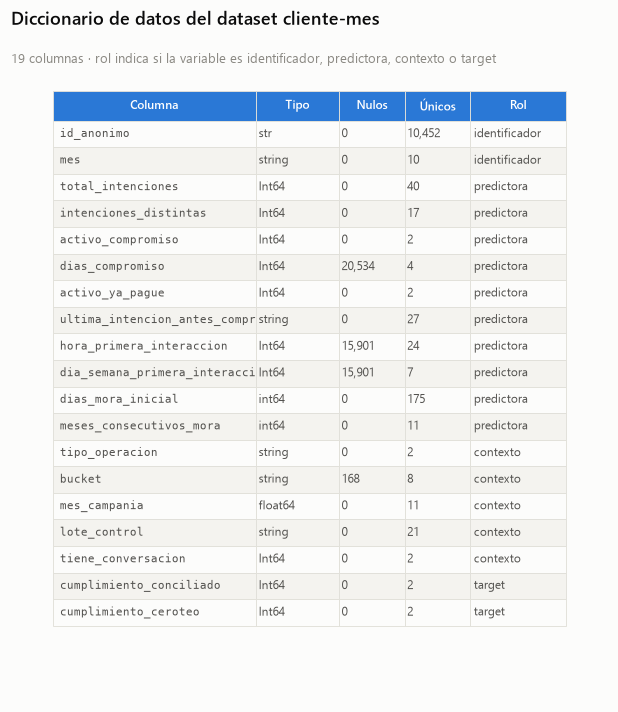

In [4]:
dicc = pd.read_csv(DIR_OUTPUTS / "diccionario_dataset_v1.csv")
dicc = dicc.rename(columns={"columna": "Columna", "tipo": "Tipo", "nulos": "Nulos",
                            "unicos": "Únicos", "rol": "Rol"})
dicc["Nulos"] = dicc["Nulos"].map(lambda v: f"{v:,}")
dicc["Únicos"] = dicc["Únicos"].map(lambda v: f"{v:,}")
display(dicc)

tabla_figura(dicc,
             "Diccionario de datos del dataset cliente-mes",
             f"{len(dicc)} columnas · rol indica si la variable es identificador, "
             "predictora, contexto o target",
             "fig09_diccionario_datos", fontsize=8,
             anchos=[0.34, 0.14, 0.11, 0.11, 0.16], mono=["Columna"])
plt.show()

---
## Figura 10 · Distribución del target

-> outputs\figuras_documento\fig10_distribucion_target.png


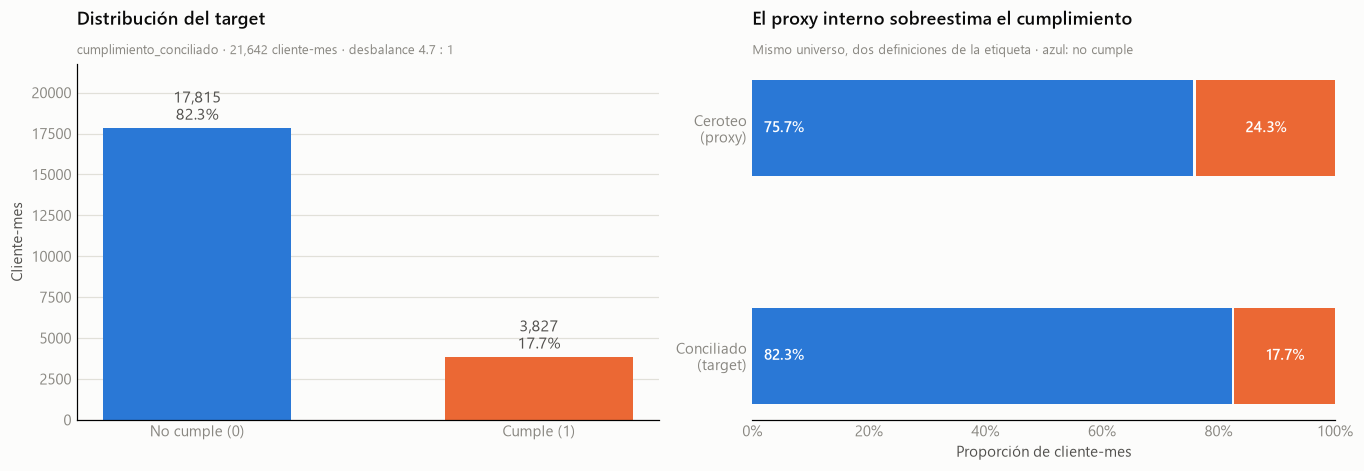

In [5]:
TARGET, PROXY = "cumplimiento_conciliado", "cumplimiento_ceroteo"
pos = int(dataset[TARGET].sum())
neg = len(dataset) - pos

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.bar(["No cumple (0)", "Cumple (1)"], [neg, pos], width=0.55, color=[AZUL, NARANJA])
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.grid(axis="y", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0, colors=MUTED)
ax.set_ylabel("Cliente-mes", color=TINTA_2)
for i, v in enumerate([neg, pos]):
    ax.text(i, v + len(dataset) * 0.012, f"{v:,}\n{v/len(dataset):.1%}",
            ha="center", va="bottom", fontsize=10.5, color=TINTA_2)
ax.set_ylim(0, neg * 1.22)
ax.text(0, 1.10, "Distribución del target", transform=ax.transAxes,
        fontsize=12, fontweight="600", color=TINTA, va="bottom")
ax.text(0, 1.02, f"cumplimiento_conciliado · {len(dataset):,} cliente-mes · "
        f"desbalance {neg/pos:.1f} : 1", transform=ax.transAxes,
        fontsize=8.5, color=MUTED, va="bottom")

ax = axes[1]
for k, (col, etiqueta) in enumerate([(TARGET, "Conciliado\n(target)"),
                                     (PROXY, "Ceroteo\n(proxy)")]):
    tasa = dataset[col].mean()
    ax.barh(k, 1 - tasa, 0.42, color=AZUL)
    ax.barh(k, tasa, 0.42, left=1 - tasa + 0.004, color=NARANJA)
    ax.text(0.02, k, f"{1-tasa:.1%}", va="center", fontsize=10,
            color="white", fontweight="600")
    ax.text(1 - tasa / 2 + 0.004, k, f"{tasa:.1%}", ha="center", va="center",
            fontsize=10, color="white", fontweight="600")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Conciliado\n(target)", "Ceroteo\n(proxy)"])
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.grid(False)
ax.tick_params(length=0, colors=MUTED)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Proporción de cliente-mes", color=TINTA_2)
ax.text(0, 1.10, "El proxy interno sobreestima el cumplimiento",
        transform=ax.transAxes, fontsize=12, fontweight="600", color=TINTA, va="bottom")
ax.text(0, 1.02, "Mismo universo, dos definiciones de la etiqueta · azul: no cumple",
        transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")

fig.tight_layout()
guardar(fig, "fig10_distribucion_target")
plt.show()

---
## Figura 11 · Normalización de cédula

In [6]:
def normalizar_cedula(serie):
    s = serie.astype("string").str.strip()
    s = s.str.replace(r"\.0+$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    return s.str.zfill(10)

def cedula_valida(c):
    if not isinstance(c, str) or len(c) != 10 or not c.isdigit():
        return False
    prov = int(c[:2])
    if not (1 <= prov <= 24 or prov == 30) or int(c[2]) > 5:
        return False
    total = 0
    for i, d in enumerate(c[:9]):
        n = int(d) * (2 if i % 2 == 0 else 1)
        total += n - 9 if n > 9 else n
    return (10 - total % 10) % 10 == int(c[9])

crudo = pd.read_csv(RAIZ / "bases" / "registros_gestion.csv", dtype=str)
crudo["cruda"] = crudo["cedula"].str.strip()
crudo["normalizada"] = normalizar_cedula(crudo["cedula"])
crudo["valida"] = crudo["normalizada"].map(cedula_valida)

# Casos representativos: los que cambian al normalizar y algunos que ya venian bien
cambian = crudo[crudo["cruda"] != crudo["normalizada"]].drop_duplicates("cruda")
iguales = crudo[crudo["cruda"] == crudo["normalizada"]].drop_duplicates("cruda").head(3)
ejemplos = pd.concat([iguales, cambian]).head(6)

filas = []
for _, r in ejemplos.iterrows():
    # enmascaradas: la figura va al documento y al repositorio.
    # se conservan los dos primeros digitos para que se vea el efecto del zfill
    def _mask(c):
        c = str(c)
        return c if len(c) < 5 else c[:2] + "*" * (len(c) - 4) + c[-2:]
    filas.append({
        "Valor de origen": _mask(r["cruda"]),
        "Dígitos": len(r["cruda"]),
        "Tras zfill(10)": _mask(r["normalizada"]),
        "¿Cédula válida?": "Sí" if r["valida"] else "No",
        "Observación": ("Sin cambios" if r["cruda"] == r["normalizada"]
                        else "Se recuperan ceros a la izquierda"),
    })
muestra_ced = pd.DataFrame(filas)
display(muestra_ced)

unicas = pd.Series(crudo["normalizada"].unique())
validas = unicas.map(cedula_valida)
largos = crudo["cruda"].str.len().value_counts().sort_index()
print(f"\nlongitudes en origen: {largos.to_dict()}")
print(f"cedulas unicas: {len(unicas):,} | validas: {int(validas.sum()):,} | "
      f"invalidas: {int((~validas).sum()):,}")

,Valor de origen,Dígitos,Tras zfill(10),¿Cédula válida?,Observación
0,01******98,10,01******98,Sí,Sin cambios
1,01******86,10,01******86,Sí,Sin cambios
2,01******36,10,01******36,Sí,Sin cambios
3,34****80,8,00******80,No,Se recuperan ceros a la izquierda
4,57**44,6,00******44,No,Se recuperan ceros a la izquierda



longitudes en origen: {6: 2, 8: 3, 10: 26194}
cedulas unicas: 12,090 | validas: 12,043 | invalidas: 47


-> outputs\figuras_documento\fig11_normalizacion_cedula.png


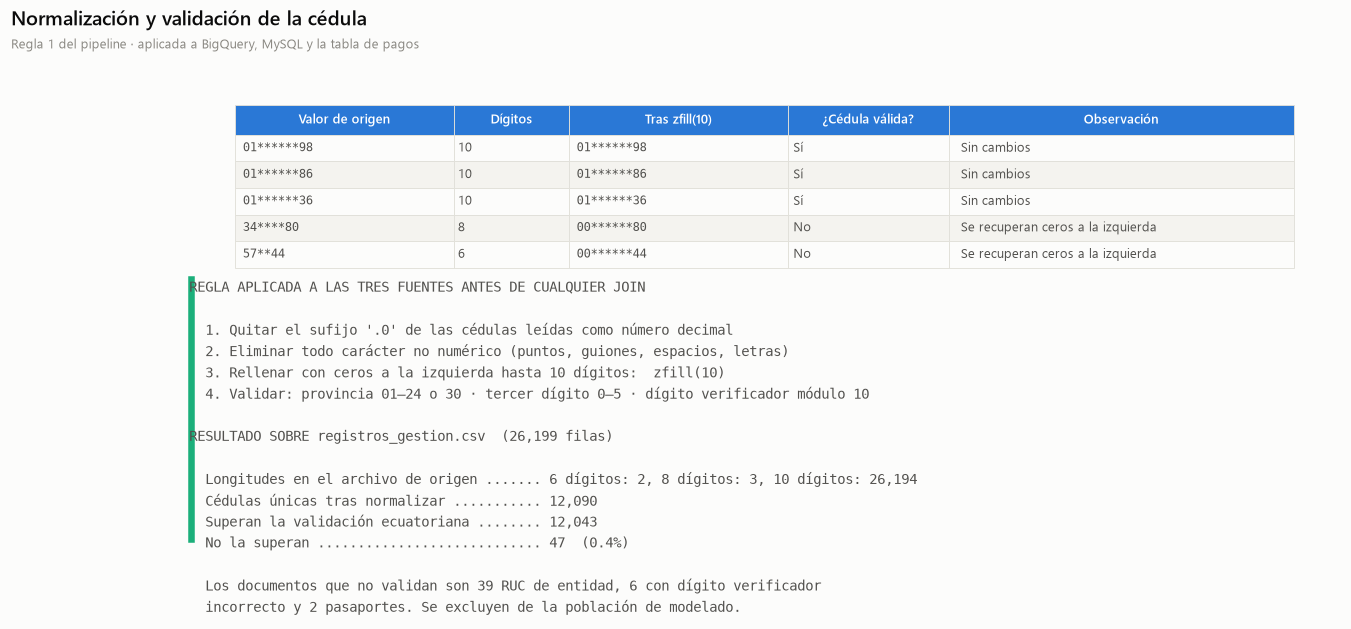

In [7]:
largos_txt = ", ".join(f"{int(k)} dígitos: {int(v):,}" for k, v in largos.items())

fig = plt.figure(figsize=(13.5, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[0.62, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
tabla_figura(muestra_ced, None, ax=ax, fontsize=8.5,
             anchos=[0.19, 0.10, 0.19, 0.14, 0.30], mono=["Valor de origen", "Tras zfill(10)"])

ax2 = fig.add_subplot(gs[1])
ax2.axis("off")
resumen = [
    "REGLA APLICADA A LAS TRES FUENTES ANTES DE CUALQUIER JOIN",
    "",
    "  1. Quitar el sufijo '.0' de las cédulas leídas como número decimal",
    "  2. Eliminar todo carácter no numérico (puntos, guiones, espacios, letras)",
    "  3. Rellenar con ceros a la izquierda hasta 10 dígitos:  zfill(10)",
    "  4. Validar: provincia 01–24 o 30 · tercer dígito 0–5 · dígito verificador módulo 10",
    "",
    f"RESULTADO SOBRE registros_gestion.csv  ({len(crudo):,} filas)",
    "",
    f"  Longitudes en el archivo de origen ....... {largos_txt}",
    f"  Cédulas únicas tras normalizar ........... {len(unicas):,}",
    f"  Superan la validación ecuatoriana ........ {int(validas.sum()):,}",
    f"  No la superan ............................ {int((~validas).sum()):,}"
    f"  ({(~validas).mean():.1%})",
    "",
    "  Los documentos que no validan son 39 RUC de entidad, 6 con dígito verificador",
    "  incorrecto y 2 pasaportes. Se excluyen de la población de modelado.",
]
ax2.text(0, 1.0, "\n".join(resumen), transform=ax2.transAxes, fontsize=9,
         family="DejaVu Sans Mono", color=TINTA_2, va="top", linespacing=1.55)
ax2.add_patch(mpl.patches.Rectangle((0, 0), 0.004, 1, transform=ax2.transAxes,
                                    color=AQUA, clip_on=False))

fig.text(0.005, 1.005, "Normalización y validación de la cédula",
         fontsize=13, fontweight="600", color=TINTA, va="bottom")
fig.text(0.005, 0.968, "Regla 1 del pipeline · aplicada a BigQuery, MySQL y la tabla de pagos",
         fontsize=8.5, color=MUTED, va="bottom")
guardar(fig, "fig11_normalizacion_cedula")
plt.show()

---
## Figura 12 · Auditoría PII

In [8]:
PATRON_COLUMNA_PII = (r"cedul|identific|documento|nombre|apellid|tarjet|card|cuenta|iban|"
                      r"direcc|domicilio|correo|e?mail|celular|tel[eé]fon|phone|movil|"
                      r"id_cliente|usuario|user")
PATRONES_VALOR = {
    "Correo electrónico": r"[\w.+-]+@[\w-]+\.[\w.]+",
    "Cédula (10 dígitos)": r"^\d{10}$",
    "Tarjeta (13–19 dígitos)": r"^\d{13,19}$",
    "Celular ecuatoriano": r"^(?:593)?0?9\d{8}$",
}

resultados = []
for nombre, patron in PATRONES_VALOR.items():
    total = 0
    for col in dataset.columns:
        if col == "id_anonimo":
            continue
        v = dataset[col].dropna().astype(str).drop_duplicates().head(5000)
        if len(v):
            total += int(v.str.match(patron).sum())
    resultados.append({"Patrón buscado": nombre, "Coincidencias": total,
                       "Resultado": "Limpio" if total == 0 else "REVISAR"})

cols_pii = [c for c in dataset.columns if re.search(PATRON_COLUMNA_PII, c, re.I)]
hash_ok = bool(dataset["id_anonimo"].str.fullmatch(r"[0-9a-f]{64}").all())
sin_colisiones = dataset["id_anonimo"].nunique()

auditoria = pd.DataFrame(resultados)
display(auditoria)
print(f"\nColumnas con nombre de dato personal en el dataset exportado: "
      f"{cols_pii if cols_pii else 'ninguna'}")
print(f"id_anonimo es SHA-256 de 64 caracteres: {hash_ok}")

,Patrón buscado,Coincidencias,Resultado
0,Correo electrónico,0,Limpio
1,Cédula (10 dígitos),0,Limpio
2,Tarjeta (13–19 dígitos),0,Limpio
3,Celular ecuatoriano,0,Limpio



Columnas con nombre de dato personal en el dataset exportado: ninguna
id_anonimo es SHA-256 de 64 caracteres: True


-> outputs\figuras_documento\fig12_auditoria_pii.png


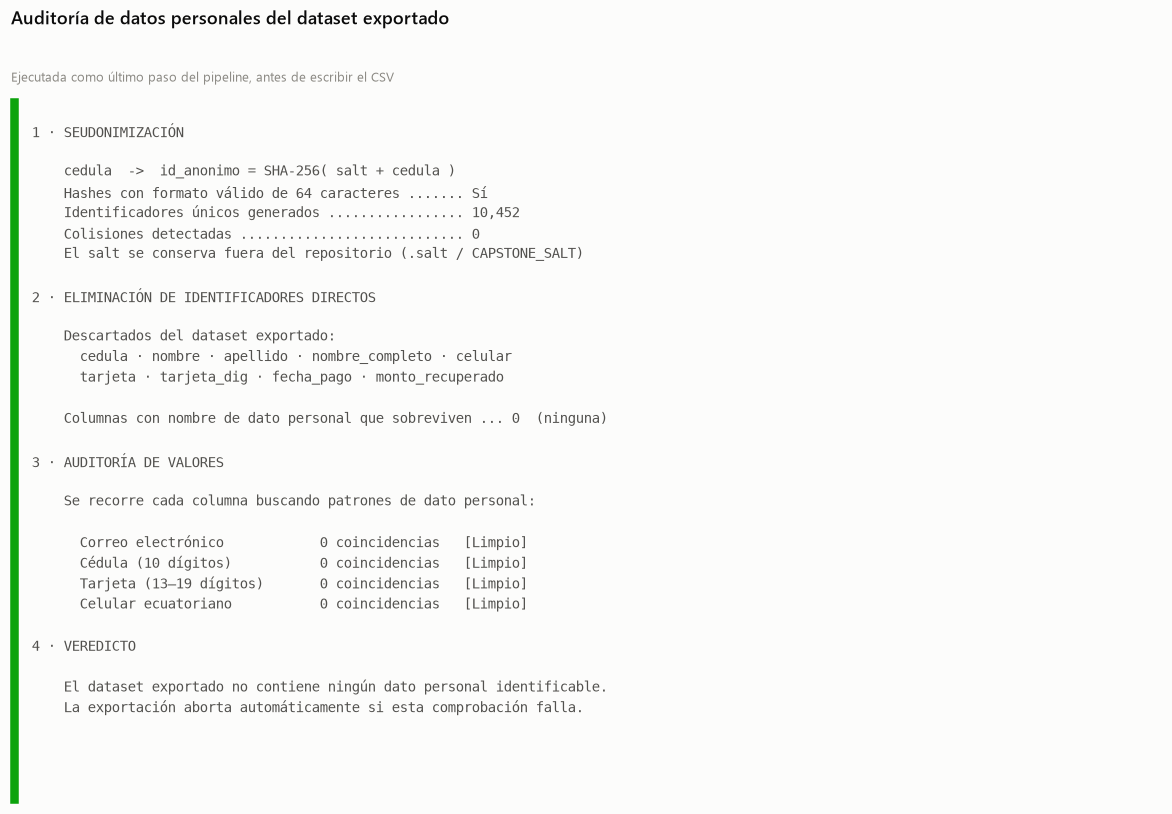

In [9]:
lineas = [
    "1 · SEUDONIMIZACIÓN",
    "",
    "    cedula  ->  id_anonimo = SHA-256( salt + cedula )",
    f"    Hashes con formato válido de 64 caracteres ....... {'Sí' if hash_ok else 'No'}",
    f"    Identificadores únicos generados ................. {sin_colisiones:,}",
    f"    Colisiones detectadas ............................ 0",
    "    El salt se conserva fuera del repositorio (.salt / CAPSTONE_SALT)",
    "",
    "2 · ELIMINACIÓN DE IDENTIFICADORES DIRECTOS",
    "",
    "    Descartados del dataset exportado:",
    "      cedula · nombre · apellido · nombre_completo · celular",
    "      tarjeta · tarjeta_dig · fecha_pago · monto_recuperado",
    "",
    f"    Columnas con nombre de dato personal que sobreviven ... "
    f"{len(cols_pii)}  ({'ninguna' if not cols_pii else cols_pii})",
    "",
    "3 · AUDITORÍA DE VALORES",
    "",
    "    Se recorre cada columna buscando patrones de dato personal:",
    "",
]
for r in resultados:
    lineas.append(f"      {r['Patrón buscado']:<26} {r['Coincidencias']:>4} coincidencias   "
                  f"[{r['Resultado']}]")
lineas += [
    "",
    "4 · VEREDICTO",
    "",
    "    El dataset exportado no contiene ningún dato personal identificable.",
    "    La exportación aborta automáticamente si esta comprobación falla.",
]

panel_texto(lineas, "Auditoría de datos personales del dataset exportado",
            "Ejecutada como último paso del pipeline, antes de escribir el CSV",
            "fig12_auditoria_pii", ancho=13.5, fontsize=9,
            color_barra=VERDE if not cols_pii else ROJO)
plt.show()

---
## Figura 13 · JSON del prototipo, tres casos

In [10]:
from motor_scoring import MotorScoring, enmascarar_cedula

motor = MotorScoring()
scores = pd.read_csv(DIR_OUTPUTS / "scores_clientemes.csv",
                     dtype={"id_anonimo": str, "mes": str})
scores = scores[scores["periodo"] == "prueba"]
scores["nivel"] = np.where(scores["score"] < 0.35, "alto",
                    np.where(scores["score"] <= 0.65, "medio", "bajo"))

crudo["id_anonimo"] = crudo["normalizada"].map(
    lambda c: hashlib.sha256((motor.salt + c).encode("utf-8")).hexdigest())
puente = crudo.merge(scores, left_on=["id_anonimo", "mes"],
                     right_on=["id_anonimo", "mes"], how="inner")

casos = []
for nivel in ["alto", "medio", "bajo"]:
    sub = puente[puente["nivel"] == nivel].sort_values("score")
    casos.append(sub.iloc[len(sub) // 2])

decisiones = [motor.consultar(c["normalizada"], c["mes"]) for c in casos]
for d in decisiones:
    print(f"{d.nivel_riesgo:<6} score={d.score:.4f}  mes={d.mes}")

alto   score=0.1138  mes=202602
medio  score=0.4516  mes=202602
bajo   score=0.7118  mes=202603


-> outputs\figuras_documento\fig13_json_prototipo.png


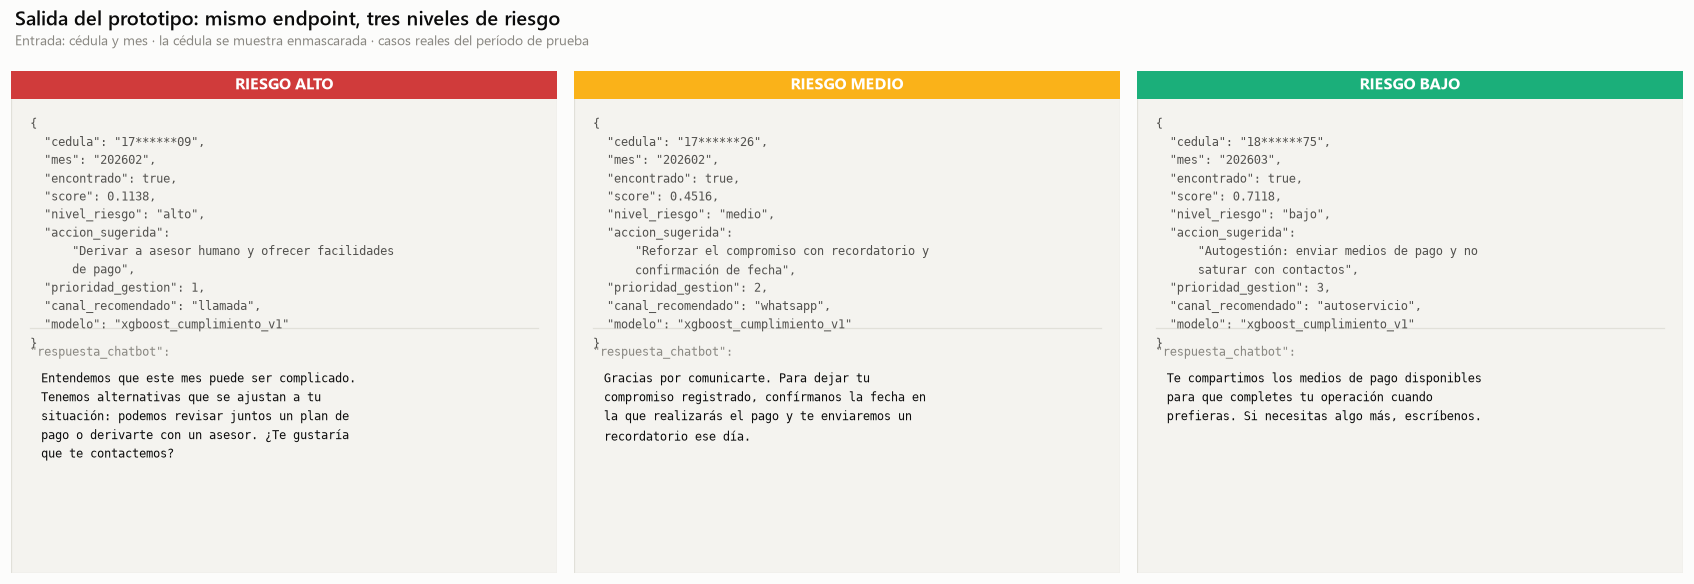

In [11]:
import textwrap

COLOR_NIVEL = {"alto": ROJO, "medio": AMARILLO, "bajo": AQUA}
ANCHO_CAR = 52          # caracteres que caben en una tarjeta a fontsize 8

def json_ajustado(dic, ancho=ANCHO_CAR):
    """Serializa el JSON partiendo los valores largos para que no se desborden."""
    lineas = ["{"]
    claves = list(dic)
    for i, k in enumerate(claves):
        v = dic[k]
        coma = "," if i < len(claves) - 1 else ""
        rendido = json.dumps(v, ensure_ascii=False)
        una_linea = f'  "{k}": {rendido}{coma}'
        if len(una_linea) <= ancho:
            lineas.append(una_linea)
        else:
            lineas.append(f'  "{k}":')
            for trozo in textwrap.wrap(rendido, ancho - 6):
                lineas.append("      " + trozo)
            lineas[-1] += coma
    lineas.append("}")
    return lineas


fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4))
for ax, d in zip(axes, decisiones):
    ax.axis("off")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    color = COLOR_NIVEL[d.nivel_riesgo]

    ax.add_patch(mpl.patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                       facecolor=FILA_ALT, edgecolor=REJILLA, lw=0.8))
    ax.add_patch(mpl.patches.Rectangle((0, 0.945), 1, 0.055, transform=ax.transAxes,
                                       facecolor=color, edgecolor="none"))
    ax.text(0.5, 0.9725, f"RIESGO {d.nivel_riesgo.upper()}", transform=ax.transAxes,
            ha="center", va="center", fontsize=10.5, fontweight="700", color="white")

    cuerpo = json.loads(d.to_json(enmascarar=True))
    respuesta = cuerpo.pop("respuesta_chatbot")
    cuerpo.pop("advertencia", None)

    lineas = json_ajustado(cuerpo)
    ax.text(0.035, 0.915, "\n".join(lineas), transform=ax.transAxes, fontsize=8,
            family="DejaVu Sans Mono", color=TINTA_2, va="top", linespacing=1.5)

    # La respuesta al cliente va debajo, separada por una línea fina
    y_sep = 0.915 - 0.0305 * (len(lineas) + 1)
    ax.plot([0.035, 0.965], [y_sep, y_sep], transform=ax.transAxes,
            color=REJILLA, linewidth=0.8)
    ax.text(0.035, y_sep - 0.035, '"respuesta_chatbot":', transform=ax.transAxes,
            fontsize=8, family="DejaVu Sans Mono", color=MUTED, va="top")
    ax.text(0.055, y_sep - 0.082, "\n".join(textwrap.wrap(respuesta, 46)),
            transform=ax.transAxes, fontsize=8, family="DejaVu Sans Mono",
            color=TINTA, va="top", linespacing=1.55)

fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.text(0.012, 0.975, "Salida del prototipo: mismo endpoint, tres niveles de riesgo",
         ha="left", va="top", fontsize=13, fontweight="600", color=TINTA)
fig.text(0.012, 0.933,
         "Entrada: cédula y mes · la cédula se muestra enmascarada · "
         "casos reales del período de prueba",
         ha="left", va="top", fontsize=9, color=MUTED)
guardar(fig, "fig13_json_prototipo")
plt.show()

---
## Índice de lo generado

In [12]:
print("=" * 66)
print("FIGURAS EN outputs/figuras_documento/")
print("=" * 66)
for ruta in sorted(DIR_FIGS.glob("*.png")):
    print(f"  {ruta.name:<40} {ruta.stat().st_size/1024:>6.0f} KB")
print()
print("Insertar en Word con Insertar > Imagen. Estan a 220 dpi, se ven nitidas")
print("al ancho de pagina y no requieren recorte.")

FIGURAS EN outputs/figuras_documento/
  fig08_primeras_filas_dataset.png            169 KB
  fig09_diccionario_datos.png                 160 KB
  fig10_distribucion_target.png               111 KB
  fig11_normalizacion_cedula.png              196 KB
  fig12_auditoria_pii.png                     177 KB
  fig13_json_prototipo.png                    243 KB

Insertar en Word con Insertar > Imagen. Estan a 220 dpi, se ven nitidas
al ancho de pagina y no requieren recorte.
